# CAPRA on own data

This self-contained example builds a `5000 x 5000` single-cell matrix, loads the bundled GenePT embeddings, and uses the same public API for splitting, training, prediction, and evaluation.

In [1]:
from pathlib import Path
import os
import sys
import warnings

cwd = Path.cwd().resolve()
repo_root = next((p for p in (cwd, *cwd.parents) if (p / "capra/frame.py").is_file()), None)
if repo_root is None:
    raise RuntimeError("Launch this notebook from the repository root or demo/.")
sys.path.insert(0, str(repo_root / "capra"))

import anndata as ad
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from frame import CAPRA, CAPRAData, load_gene_embedding_table

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning,
                        message="DataFrame is highly fragmented.*")
torch.set_num_threads(min(4, os.cpu_count() or 1))


In [2]:
demo_name = "demo_own_data"
condition_key, perturbation_key = "condition", "perturbation"
seed, n_pred, val_n_pred, num_workers = 24, 16, 16, 0
accelerator = "gpu"
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required for this demo.")
output_dir = Path(os.environ.get("CAPRA_DEMO_OUTPUT_ROOT", str(repo_root / "demo/outputs"))) / demo_name
embedding_path = repo_root / "demo/data/norman_example_genept_embeddings.pkl"


## 1. Build the input data

A self-contained `5000 x 5000` sparse matrix is simulated: each condition applies a perturbation-specific fold change to the perturbed genes and their neighbours, followed by normalization and `log1p`. Perturbation genes are drawn from the bundled GenePT table (`demo/data/norman_example_genept_embeddings.pkl`), and a zero embedding row is added for the control anchor.

In [3]:
from scipy import sparse
import scanpy as sc

rng = np.random.default_rng(seed)
embedding_table = load_gene_embedding_table(embedding_path, add_control=False)
perturbation_genes = [
    "CEBPB", "FOS", "GATA1", "IRF1", "JUN", "MYC", "STAT1", "CEBPA",
    "KLF1", "MAP2K6", "SET", "TGFBR2", "FOXA1", "NFE2", "SMARCA2",
]
assert set(perturbation_genes).issubset(embedding_table.index)
embedding_table.loc["ctrl"] = np.zeros(embedding_table.shape[1], dtype=np.float32)

genes = list(embedding_table.index.drop("ctrl"))
genes += [f"GENE_{index:04d}" for index in range(5000 - len(genes))]
assert len(genes) == 5000 and len(set(genes)) == 5000

doubles = [
    "CEBPB+FOS", "GATA1+IRF1", "JUN+MYC", "STAT1+CEBPA",
    "KLF1+MAP2K6", "SET+TGFBR2", "FOXA1+NFE2", "SMARCA2+CEBPB",
]
conditions = ["control", *perturbation_genes, *doubles]
counts_per_condition = {"control": 300}
base, extra = divmod(5000 - counts_per_condition["control"], len(conditions) - 1)
for index, condition in enumerate(conditions[1:]):
    counts_per_condition[condition] = base + int(index < extra)

position = {gene: index for index, gene in enumerate(genes)}
base_expression = rng.lognormal(mean=-2.0, sigma=0.85, size=len(genes))
blocks, labels = [], []
for condition in conditions:
    fold = np.ones(len(genes))
    for gene in [] if condition == "control" else condition.split("+"):
        index = position[gene]
        fold[index] *= 0.25
        for offset, multiplier in ((32, 1.8), (96, 0.65), (160, 1.35)):
            fold[(index + np.arange(12) + offset) % len(genes)] *= multiplier
    mean = base_expression[None, :] * fold[None, :]
    mean = mean * rng.lognormal(0, 0.45, size=(counts_per_condition[condition], 1))
    counts = rng.poisson(rng.gamma(2.0, mean / 2.0)).astype(np.float32)
    blocks.append(sparse.csr_matrix(counts))
    labels.extend([condition] * counts_per_condition[condition])

adata = ad.AnnData(
    X=sparse.vstack(blocks, format="csr"),
    obs=pd.DataFrame({condition_key: labels, perturbation_key: labels},
                     index=[f"own_cell_{i:04d}" for i in range(5000)]),
    var=pd.DataFrame(index=genes),
)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
assert adata.shape == (5000, 5000)
print("AnnData:", adata.shape, "| GenePT:", embedding_table.shape)
print("Conditions:", len(conditions) - 1, "| Controls:", counts_per_condition["control"])


AnnData: (5000, 5000) | GenePT: (4995, 3072)
Conditions: 23 | Controls: 300


## 2. Prepare with the CAPRA API

`CAPRAData` holds the AnnData and embedding table and prepares them for training:

- `harmonize_perturbation_metadata()` canonicalizes `+`-separated perturbation labels.
- `register_evaluation_partitions(split_strategy="auto", random_state=...)` splits conditions into train / validation / test sets.
- `estimate_trainval_deg_reference(method="t-test")` ranks the Top-100 differentially expressed genes per condition from training cells.
- `build_control_relative_training_state()` samples control means and builds the control-relative training batches.

In [4]:
data = CAPRAData(
    adata=adata, embedding_table=embedding_table, study_name=demo_name,
    condition_key=condition_key, perturbation_key=perturbation_key,
)
data.harmonize_perturbation_metadata(copy=False)
data.register_evaluation_partitions(split_strategy="auto", random_state=1)
data.estimate_trainval_deg_reference(method="t-test")
data.build_control_relative_training_state()
print("Splits:", {key: len(value) for key, value in data.splits.items()})


Splits: {'train': 16, 'val': 1, 'test': 6}


## 3. Train and predict

- `CAPRA(data)` builds the control-anchored response operator from the prepared data.
- `fit_capra_response_operator(n_epochs=..., seed=...)` trains the operator; the best checkpoint is kept for reload.
- `generate_counterfactual_profiles(pert_list, n_pred)` predicts `n_pred` counterfactual profiles per held-out condition.

In [5]:
model = CAPRA(data)
model.fit_capra_response_operator(
    output_dir=output_dir / "results", run_name=f"{demo_name}_seed{seed}",
    n_epochs=1, min_epochs=1, seed=seed, accelerator=accelerator,
    precision="16-mixed", num_workers=num_workers, pin_memory=True,
    val_n_pred=val_n_pred,
)
test_conditions = list(data.splits["test"])[:3]
predictions = model.generate_counterfactual_profiles(
    pert_list=test_conditions, n_pred=n_pred,
)
print("Predicted:", {key: value.shape for key, value in predictions.items()})


CAPRA training | epoch 1/1 | train_loss=1.5268 | val_unseen_loss=0.5438 | monitor=0.7504 | patience=0/10


Predicted: {'FOXA1': (16, 5000), 'FOXA1+NFE2': (16, 5000), 'GATA1+IRF1': (16, 5000)}


## 4. Inspect the response

Compare predicted against observed responses (condition mean minus control mean) on a held-out condition: Pearson correlation over all genes, the Top-10 responding genes, and a response scatter plot.

Held-out: FOXA1 | Pearson r: 0.1366


,observed_delta,predicted_delta
FTL,0.4298,-0.3863
GOLT1A,0.4160,-0.0991
MXD3,0.4052,0.0772
GCHFR,-0.3739,-0.2591
GLT8D2,-0.3450,-0.1577
JMJD1C,-0.3414,-0.3283
FUNDC1,0.3318,0.4211
IFI6,0.3289,-0.2297
CCDC14,-0.3266,-0.2754
FUCA1,0.3209,-0.1316


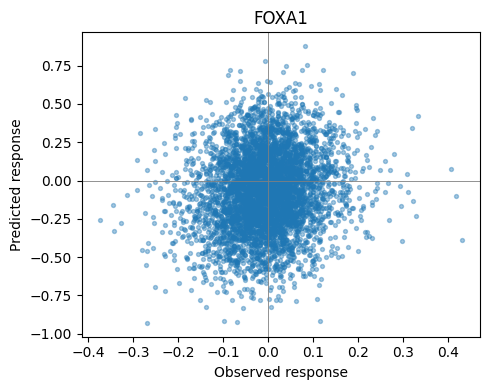

In [6]:
import matplotlib.pyplot as plt

condition = test_conditions[0]
labels = data.adata.obs["perturbation"].astype(str)
control_mean = np.asarray(data.adata[labels == "control"].X.mean(axis=0)).ravel()
observed_mean = np.asarray(data.adata[labels == condition].X.mean(axis=0)).ravel()
predicted_mean = predictions[condition].mean(axis=0)
response = pd.DataFrame({
    "observed_delta": observed_mean - control_mean,
    "predicted_delta": predicted_mean - control_mean,
}, index=data.adata.var_names)
pearson = np.corrcoef(response["observed_delta"], response["predicted_delta"])[0, 1]
print("Held-out:", condition, "| Pearson r:", round(float(pearson), 4))
display(response.loc[response["observed_delta"].abs().nlargest(10).index].round(4))
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(response["observed_delta"], response["predicted_delta"], s=8, alpha=0.4)
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(0, color="grey", linewidth=0.6)
ax.set(xlabel="Observed response", ylabel="Predicted response", title=condition)
fig.tight_layout()
plt.show()


## 5. Export and reload

Predictions are exported as one AnnData file, and `load_capra_response_operator(checkpoint)` restores the trained operator from the best checkpoint and reproduces the same predictions.

In [7]:
blocks = []
for pert, matrix in predictions.items():
    assert matrix.shape == (n_pred, data.adata.n_vars)
    blocks.append(ad.AnnData(
        X=matrix.astype(np.float32),
        obs=pd.DataFrame({"condition": pert, "perturbation": pert},
                    index=[f"{pert}_{j:03d}" for j in range(n_pred)]),
        var=pd.DataFrame(index=data.adata.var_names),
    ))
prediction_adata = ad.concat(blocks, merge="same")
output_dir.mkdir(parents=True, exist_ok=True)
prediction_path = output_dir / "predictions.h5ad"
prediction_adata.write_h5ad(prediction_path)

checkpoint = model.fitted["metrics"]["best_checkpoint"]
loaded = CAPRA(data)
loaded.load_capra_response_operator(checkpoint, accelerator=accelerator,
                                    output_dir=output_dir / "results")
reloaded = loaded.generate_counterfactual_profiles(
    pert_list=[condition], n_pred=n_pred, sampling_state=seed,
)[condition]
np.testing.assert_allclose(reloaded, predictions[condition], rtol=1e-5, atol=1e-5)
print("Reload verified:", condition)


Reload verified: FOXA1
